<a href="https://colab.research.google.com/github/jiw0n-lee/Pattern-Recognition/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. setting

In [ ]:
!pip install optuna --quiet

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics        import f1_score, roc_auc_score, roc_curve, \
                                   confusion_matrix, ConfusionMatrixDisplay, \
                                   precision_score, recall_score
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.8 MB/s eta 0:00:00


# 1. Data Load and Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 구글 드라이브 내 데이터가 저장된 폴더 경로로 대체
base_path = '/content/drive/MyDrive/PR_team_project/data'
os.chdir(base_path)

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

test_id = test['id']

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train.head())
display(test.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (39073, 15)
Test shape: (9769, 14)


,id,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,37194,50,Private,Masters,14,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,35,United-States,<=50K
1,31094,28,Private,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,40,United-States,<=50K
2,33815,29,Private,HS-grad,9,Married-civ-spouse,Other-service,Wife,White,Female,0,1902,35,United-States,>50K
3,14501,32,Private,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K
4,23400,62,State-gov,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K


,id,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,7763,28,Private,Some-college,10,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States
1,23882,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States
2,30508,46,Self-emp-not-inc,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Black,Male,0,0,23,United-States
3,28912,39,Private,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,35,United-States
4,19485,21,State-gov,Some-college,10,Never-married,Other-service,Own-child,White,Female,0,0,25,United-States


## 기본 정보 확인

In [ ]:
print("===== Train Info =====")
train.info()

print("\n===== Test Info =====")
test.info()

===== Train Info =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              39073 non-null  int64 
 1   age             39073 non-null  int64 
 2   workclass       36860 non-null  object
 3   education       39073 non-null  object
 4   education_num   39073 non-null  int64 
 5   marital_status  39073 non-null  object
 6   occupation      36850 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital_gain    39073 non-null  int64 
 11  capital_loss    39073 non-null  int64 
 12  hours_per_week  39073 non-null  int64 
 13  native_country  38395 non-null  object
 14  income          39073 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.5+ MB

===== Test Info =====
<class 'pandas.core.frame.DataFrame'>
RangeInde

## 결측치 확인

" ?" 형태의 결측치를 NaN으로 변환

In [ ]:
train = train.replace(" ?", np.nan)
test = test.replace(" ?", np.nan)

print("===== Train Missing Values =====")
print(train.isnull().sum())

print("\n===== Test Missing Values =====")
print(test.isnull().sum())

===== Train Missing Values =====
id                   0
age                  0
workclass         2213
education            0
education_num        0
marital_status       0
occupation        2223
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     678
income               0
dtype: int64

===== Test Missing Values =====
id                  0
age                 0
workclass         586
education           0
education_num       0
marital_status      0
occupation        586
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    179
dtype: int64


## 변수 타입 분류

In [ ]:
target_col = "income"

cat_cols = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

num_cols = [
    "age",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Numerical columns: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


## Class Distribution 확인

income
<=50K    29729
>50K      9344
Name: count, dtype: int64
income
<=50K    0.760858
>50K     0.239142
Name: proportion, dtype: float64


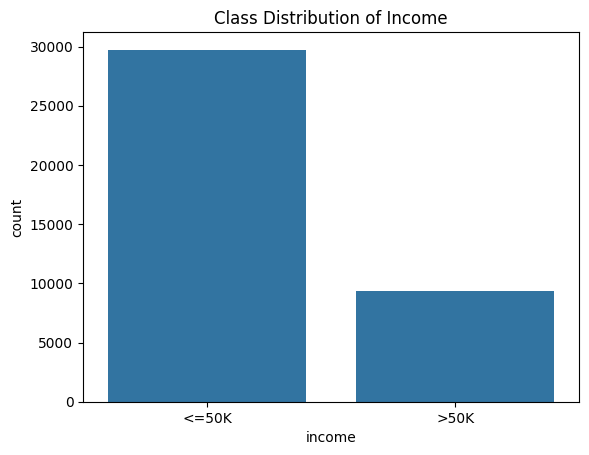

In [ ]:
print(train[target_col].value_counts())
print(train[target_col].value_counts(normalize=True))

sns.countplot(x=target_col, data=train)
plt.title("Class Distribution of Income")
plt.show()

## 수치형 변수 요약 및 시각화

In [ ]:
display(train[num_cols].describe())

,age,education_num,capital_gain,capital_loss,hours_per_week
count,39073.000000,39073.000000,39073.000000,39073.000000,39073.000000
mean,38.644486,10.073452,1103.252502,87.473242,40.419011
std,13.684477,2.573804,7631.435106,403.466717,12.382864
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


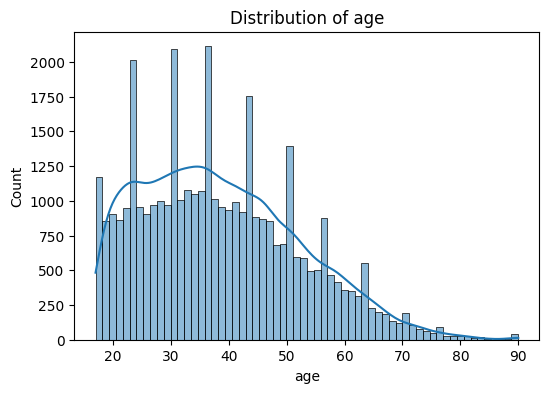

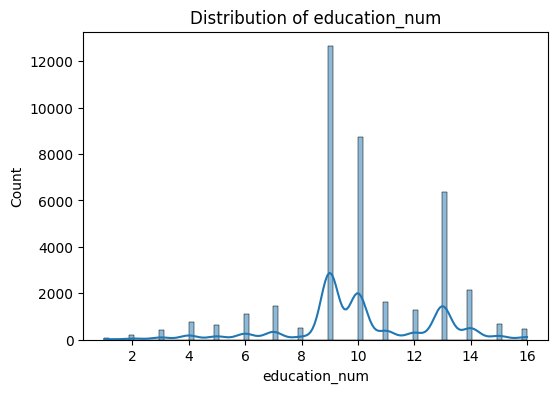

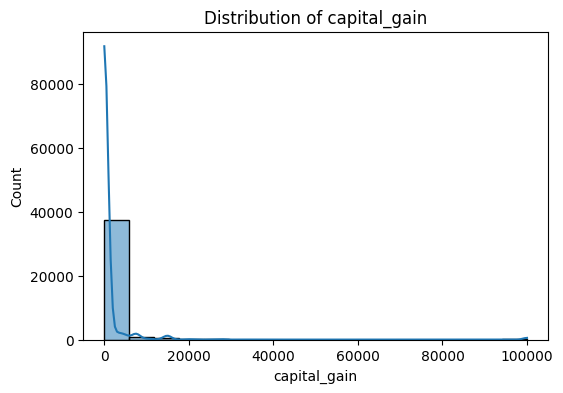

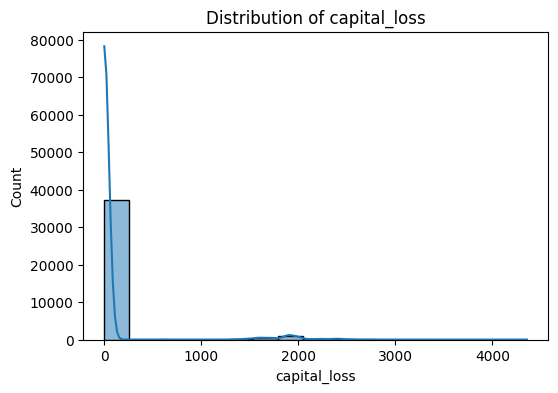

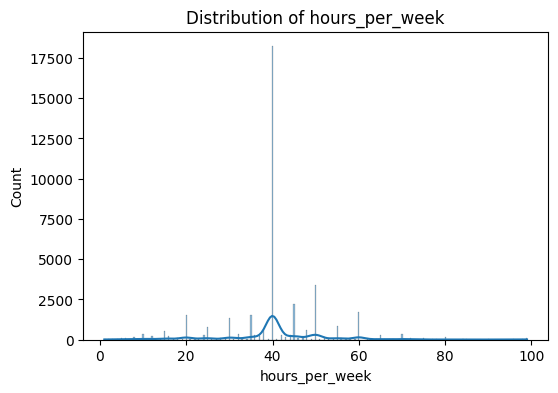

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## 범주형 변수 분포 확인

In [ ]:
for col in cat_cols:
    print(f"\n===== {col} =====")
    print(train[col].value_counts())


===== workclass =====
workclass
Private             27208
Self-emp-not-inc     3112
Local-gov            2483
State-gov            1574
Self-emp-inc         1315
Federal-gov          1142
Without-pay            16
Never-worked           10
Name: count, dtype: int64

===== education =====
education
HS-grad         12646
Some-college     8744
Bachelors        6343
Masters          2140
Assoc-voc        1627
11th             1455
Assoc-acdm       1278
10th             1108
7th-8th           771
Prof-school       691
9th               611
12th              513
Doctorate         473
5th-6th           406
1st-4th           200
Preschool          67
Name: count, dtype: int64

===== marital_status =====
marital_status
Married-civ-spouse       17950
Never-married            12809
Divorced                  5328
Separated                 1233
Widowed                   1221
Married-spouse-absent      504
Married-AF-spouse           28
Name: count, dtype: int64

===== occupation =====
occupation
P

## 결측치 처리

범주형 변수: 최빈값으로 대체

수치형 변수: 중앙값으로 대체


In [ ]:
for col in cat_cols:
    mode_value = train[col].mode()[0]

    train[col] = train[col].fillna(mode_value)
    test[col] = test[col].fillna(mode_value)

for col in num_cols:
    median_value = train[col].median()

    train[col] = train[col].fillna(median_value)
    test[col] = test[col].fillna(median_value)

print("결측치 처리 후 train:")
print(train.isnull().sum())

print("\n결측치 처리 후 test:")
print(test.isnull().sum())

결측치 처리 후 train:
id                0
age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

결측치 처리 후 test:
id                0
age               0
workclass         0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
dtype: int64


## Target Encoding

5만 이하 -> 0

5만 초과 -> 1

In [ ]:
train[target_col] = train[target_col].map({
    "<=50K": 0,
    ">50K": 1
})

print(train[target_col].value_counts())

income
0    29729
1     9344
Name: count, dtype: int64


## Categorical Encoding
Label Encoding 사용

train/test를 함께 fit해서 unseen category 문제 방지

In [ ]:
encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    combined = pd.concat([train[col], test[col]], axis=0)

    le.fit(combined)

    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

    encoders[col] = le

display(train.head())

,id,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,37194,50,3,12,14,0,9,1,4,0,0,0,35,38,0
1,31094,28,3,15,10,4,3,1,4,0,0,0,40,38,0
2,33815,29,3,11,9,2,7,5,4,0,0,1902,35,38,1
3,14501,32,3,11,9,4,0,1,4,0,0,0,40,38,0
4,23400,62,6,11,9,2,13,0,4,1,0,0,40,38,0


## Feature Engineering

capital_gain과 capital_loss를 합친 변수 생성

In [ ]:
train["capital_total"] = (
    train["capital_gain"]
    - train["capital_loss"]
)

test["capital_total"] = (
    test["capital_gain"]
    - test["capital_loss"]
)

num_cols.append("capital_total")

## Scaling

수치형 변수 표준화

In [ ]:
scaler = StandardScaler()

train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

display(train.head())

,id,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_total
0,37194,0.829820,3,12,1.525601,0,9,1,4,0,-0.144569,-0.216807,-0.437627,38,0,-0.132702
1,31094,-0.777861,3,15,-0.028539,4,3,1,4,0,-0.144569,-0.216807,-0.033838,38,0,-0.132702
2,33815,-0.704785,3,11,-0.417074,2,7,5,4,0,-0.144569,4.497397,-0.437627,38,1,-0.381179
3,14501,-0.485555,3,11,-0.417074,4,0,1,4,0,-0.144569,-0.216807,-0.033838,38,0,-0.132702
4,23400,1.706738,6,11,-0.417074,2,13,0,4,1,-0.144569,-0.216807,-0.033838,38,0,-0.132702


### 최종 데이터 분리

In [ ]:
train_X_df = train.drop(columns=[target_col])
train_y_df = train[target_col]

test_X_df = test.copy()

x_train = train_X_df.drop(columns=['id'], errors='ignore')
y_train = train_y_df.squeeze()
test_X_df = test_X_df.drop(columns=['id'], errors='ignore')

print(f'Train: {x_train.shape}  |  Test: {test_X_df.shape}')
print(f'Target 분포:\n{y_train.value_counts()}')

Train: (39073, 14)  |  Test: (9769, 14)
Target 분포:
income
0    29729
1     9344
Name: count, dtype: int64


# 2. Basic Model

## (1) Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score

# 1. 로지스틱 회귀 모델 정의
logreg = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced"
)

# 2. 전체 train 데이터로 학습
logreg.fit(x_train, y_train)

# =========================
# (A) TRAIN 성능 평가
# =========================
y_prob_train = logreg.predict_proba(x_train)[:, 1]       # train에서의 확률
y_pred_train = (y_prob_train >= 0.5).astype(int)        # 0/1로 변환

f1_train  = f1_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_prob_train)
score_train = (f1_train + auc_train) / 2

print("Train F1:", f1_train)
print("Train AUC:", auc_train)
print("Train Score((F1+AUC)/2):", score_train)


Train F1: 0.6115631691648822
Train AUC: 0.8531438852802509
Train Score((F1+AUC)/2): 0.7323535272225665


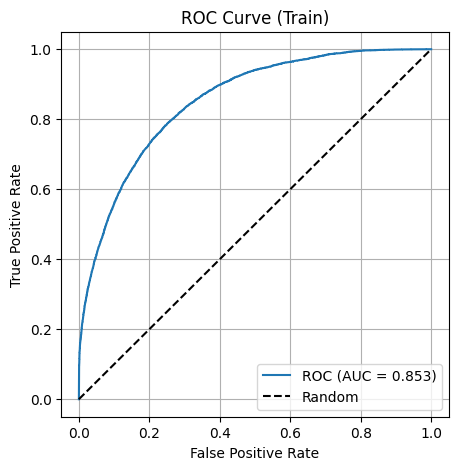

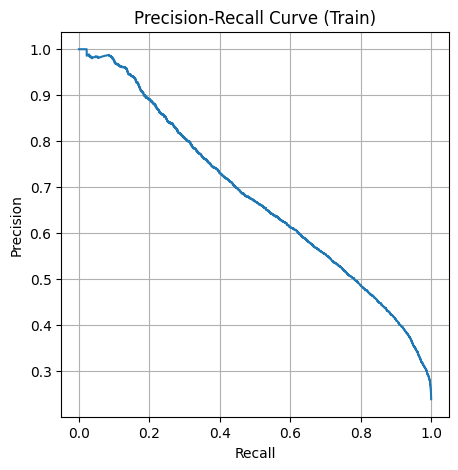

<Figure size 400x400 with 0 Axes>

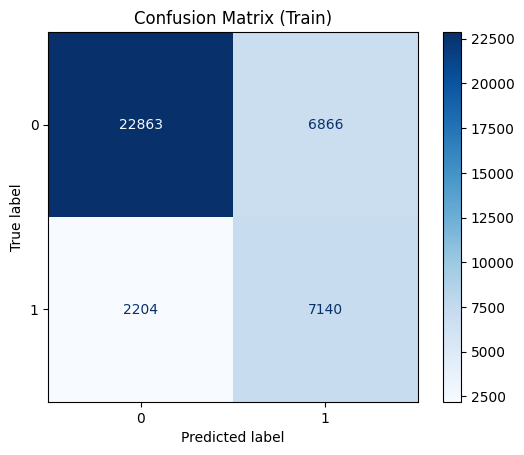

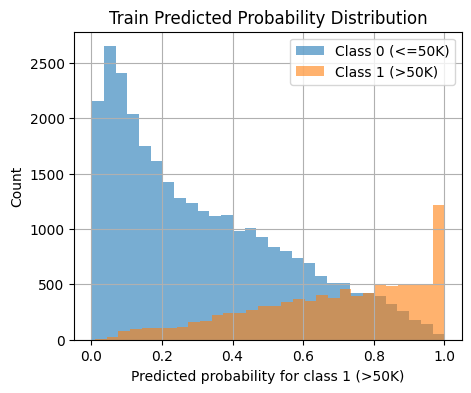

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# 이미 계산한 것들:
# y_train, y_prob_train, y_pred_train, f1_train, auc_train

# 1. ROC Curve
fpr, tpr, thresholds = roc_curve(y_train, y_prob_train)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_train:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train)")
plt.legend()
plt.grid(True)
plt.show()

# 2. Precision-Recall Curve
prec, rec, thr = precision_recall_curve(y_train, y_prob_train)
plt.figure(figsize=(5, 5))
plt.plot(rec, prec, label="PR curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Train)")
plt.grid(True)
plt.show()

# 3. Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Train)")
plt.show()

# 4. 예측 확률 분포 (선택)
plt.figure(figsize=(5, 4))
plt.hist(y_prob_train[y_train == 0], bins=30, alpha=0.6, label="Class 0 (<=50K)")
plt.hist(y_prob_train[y_train == 1], bins=30, alpha=0.6, label="Class 1 (>50K)")
plt.xlabel("Predicted probability for class 1 (>50K)")
plt.ylabel("Count")
plt.title("Train Predicted Probability Distribution")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =========================
# (B) TEST 예측 (제출용)
# =========================
# 전처리된 test 특징 행렬 이름이 test_X_df 라고 가정
y_prob_test = logreg.predict_proba(test_X_df)[:, 1]      # class 1 (>50K) 확률
y_cls_test  = (y_prob_test >= 0.5).astype(int)          # 0/1로 변환

# test의 id는 따로 갖고 있다고 가정: test_id (또는 test_df["id"])
submission_lr = pd.DataFrame({
    "id": test_id,
    "y_cls": y_cls_test,
    "y_prob": y_prob_test
})
# submission_lr.to_csv("prediction_lr.csv", index=False)
# print("prediction_lr.csv 저장 완료")

print(submission_lr.head())


      id  y_cls    y_prob
0   7763      0  0.196528
1  23882      1  0.599533
2  30508      0  0.374689
3  28912      1  0.985324
4  19485      0  0.035987


## (2) Random Forest Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

# 1. 랜덤포레스트 모델 정의
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # 불균형 대응
)

# 2. 학습
rf.fit(x_train, y_train)

# =========================
# (A) TRAIN 성능 평가
# =========================
y_prob_train_rf = rf.predict_proba(x_train)[:, 1]
y_pred_train_rf = (y_prob_train_rf >= 0.5).astype(int)

f1_train_rf  = f1_score(y_train, y_pred_train_rf)
auc_train_rf = roc_auc_score(y_train, y_prob_train_rf)
score_train_rf = (f1_train_rf + auc_train_rf) / 2

print("Train F1:", f1_train_rf)
print("Train AUC:", auc_train_rf)
print("Train Score((F1+AUC)/2):", score_train_rf)


Train F1: 0.6564481181285611
Train AUC: 0.9024255678550808
Train Score((F1+AUC)/2): 0.7794368429918209


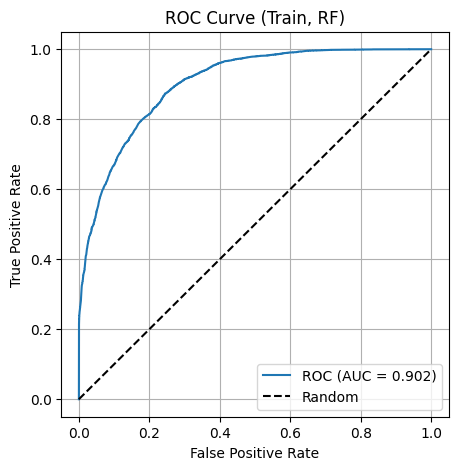

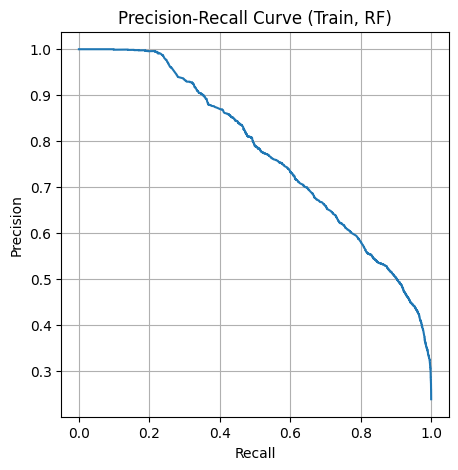

<Figure size 400x400 with 0 Axes>

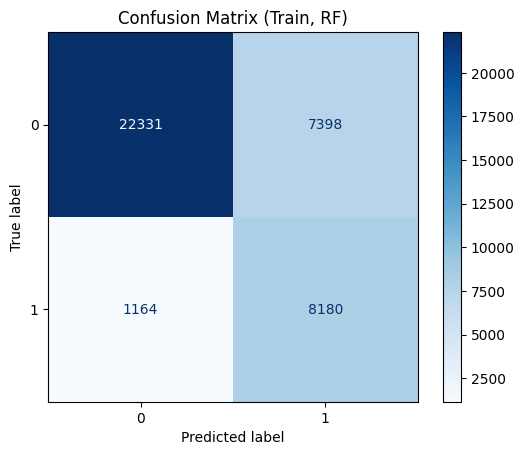

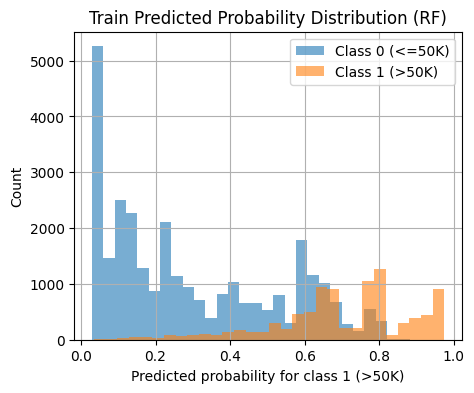

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# 이미 계산된 것:
# y_train, y_prob_train_rf, y_pred_train_rf, auc_train_rf

# 1. ROC Curve  ← y_prob_train_rf 사용해야 함
fpr, tpr, thresholds = roc_curve(y_train, y_prob_train_rf)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_train_rf:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train, RF)")
plt.legend()
plt.grid(True)
plt.show()

# 2. Precision-Recall Curve  ← 이 부분은 변수만 맞으면 OK
prec, rec, thr = precision_recall_curve(y_train, y_prob_train_rf)
plt.figure(figsize=(5, 5))
plt.plot(rec, prec, label="PR curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Train, RF)")
plt.grid(True)
plt.show()

# 3. Confusion Matrix  ← (정답 y, 예측 label)을 넣어야 함
cm = confusion_matrix(y_train, y_pred_train_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(4, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Train, RF)")
plt.show()

# 4. 예측 확률 분포
plt.figure(figsize=(5, 4))
plt.hist(y_prob_train_rf[y_train == 0], bins=30, alpha=0.6, label="Class 0 (<=50K)")
plt.hist(y_prob_train_rf[y_train == 1], bins=30, alpha=0.6, label="Class 1 (>50K)")
plt.xlabel("Predicted probability for class 1 (>50K)")
plt.ylabel("Count")
plt.title("Train Predicted Probability Distribution (RF)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =========================
# (B) TEST 예측 (제출용) - Random Forest
# =========================
y_prob_test_rf = rf.predict_proba(test_X_df)[:, 1]      # class 1 (>50K) 확률
y_cls_test_rf  = (y_prob_test_rf >= 0.5).astype(int)    # 0/1로 변환

submission_rf = pd.DataFrame({
    "id": test_id,
    "y_cls": y_cls_test_rf,
    "y_prob": y_prob_test_rf
})
# submission_rf.to_csv("prediction_rf.csv", index=False)
# print("prediction_rf.csv 저장 완료")

print(submission_rf.head())


      id  y_cls    y_prob
0   7763      0  0.087656
1  23882      1  0.602403
2  30508      0  0.316532
3  28912      1  0.910102
4  19485      0  0.039928


## (3) XGBoost

트리 모델 앙상블, 과적합 방지에 유리

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
import pandas as pd

# 1. XGBoost 기본 모델 정의
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

# 2. 학습
xgb.fit(x_train, y_train)

# 3. (선택) train 성능 평가
y_prob_train_xgb = xgb.predict_proba(x_train)[:, 1]
y_pred_train_xgb = (y_prob_train_xgb >= 0.5).astype(int)

f1_train_xgb  = f1_score(y_train, y_pred_train_xgb)
auc_train_xgb = roc_auc_score(y_train, y_prob_train_xgb)
score_train_xgb = (f1_train_xgb + auc_train_xgb) / 2

print("Train F1:", f1_train_xgb)
print("Train AUC:", auc_train_xgb)
print("Train Score:", score_train_xgb)

Train F1: 0.744067304902814
Train AUC: 0.9448293649897683
Train Score: 0.8444483349462912


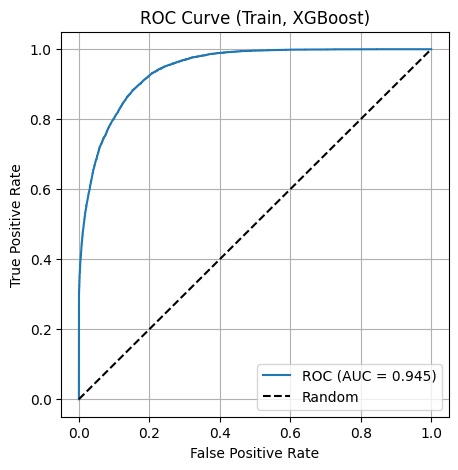

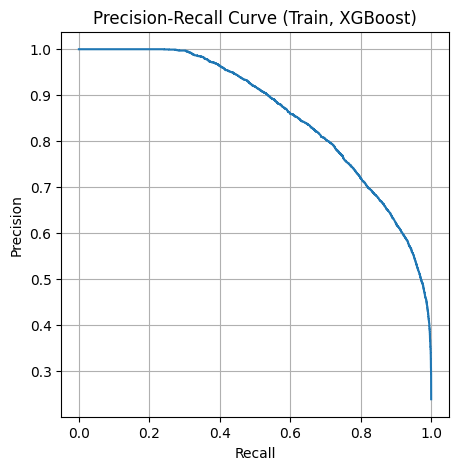

<Figure size 400x400 with 0 Axes>

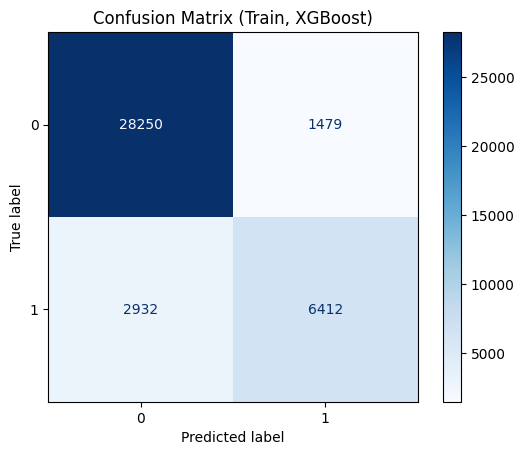

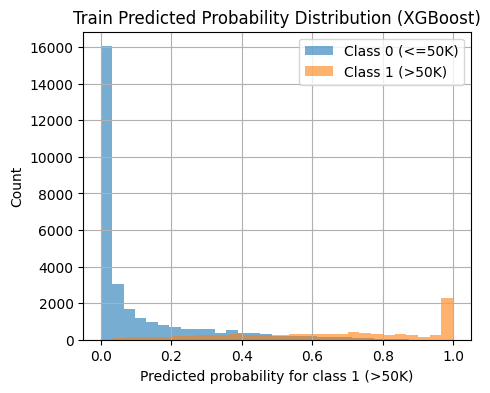

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# 1. ROC Curve (XGBoost)
fpr_xgb, tpr_xgb, thr_xgb = roc_curve(y_train, y_prob_train_xgb)
plt.figure(figsize=(5, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f"ROC (AUC = {auc_train_xgb:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Train, XGBoost)")
plt.legend()
plt.grid(True)
plt.show()

# 2. Precision-Recall Curve (XGBoost)
prec_xgb, rec_xgb, thr_pr_xgb = precision_recall_curve(y_train, y_prob_train_xgb)
plt.figure(figsize=(5, 5))
plt.plot(rec_xgb, prec_xgb, label="PR curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Train, XGBoost)")
plt.grid(True)
plt.show()

# 3. Confusion Matrix (XGBoost)
cm_xgb = confusion_matrix(y_train, y_pred_train_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
plt.figure(figsize=(4, 4))
disp_xgb.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Train, XGBoost)")
plt.show()

# 4. 예측 확률 분포 (XGBoost)
plt.figure(figsize=(5, 4))
plt.hist(y_prob_train_xgb[y_train == 0], bins=30, alpha=0.6, label="Class 0 (<=50K)")
plt.hist(y_prob_train_xgb[y_train == 1], bins=30, alpha=0.6, label="Class 1 (>50K)")
plt.xlabel("Predicted probability for class 1 (>50K)")
plt.ylabel("Count")
plt.title("Train Predicted Probability Distribution (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 4. TEST 예측 (제출용)
y_prob_test_xgb = xgb.predict_proba(test_X_df)[:, 1]
y_cls_test_xgb  = (y_prob_test_xgb >= 0.5).astype(int)

submission_xgb = pd.DataFrame({
    "id": test_id,
    "y_cls": y_cls_test_xgb,
    "y_prob": y_prob_test_xgb
})
# submission_xgb.to_csv("prediction_xgb.csv", index=False)
# print("prediction_xgb.csv 저장 완료")

print(submission_xgb.head())


      id  y_cls    y_prob
0   7763      0  0.004055
1  23882      0  0.284035
2  30508      0  0.099911
3  28912      1  0.998976
4  19485      0  0.000227


## 결과 비교


In [ ]:
models = {
    "logreg": logreg,  # 이미 위에서 학습시킨 로지스틱 회귀
    "rf": rf,          # 이미 학습시킨 랜덤포레스트
    "xgb": xgb         # 이미 학습시킨 XGBoost
}

results = []

for name, model in models.items():
    # 1. train에 대한 확률 / 라벨 예측
    y_prob = model.predict_proba(x_train)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # 2. 지표 계산
    f1  = f1_score(y_train, y_pred)
    auc = roc_auc_score(y_train, y_prob)
    score = (f1 + auc) / 2

    results.append({
        "model": name,
        "F1_train": f1,
        "AUC_train": auc,
        "Score_train": score
    })

results_df = pd.DataFrame(results).sort_values("Score_train", ascending=False)
print(results_df)


    model  F1_train  AUC_train  Score_train
2     xgb  0.744067   0.944829     0.844448
1      rf  0.656448   0.902426     0.779437
0  logreg  0.611563   0.853144     0.732354


## 결과 분석
- XGB 모델 base 피처 중요도 분석

           feature  importance
0     relationship    0.277340
1   marital_status    0.167379
2     capital_gain    0.123803
3    education_num    0.120006
4    capital_total    0.092796
5     capital_loss    0.055835
6              age    0.032848
7   hours_per_week    0.026381
8       occupation    0.025912
9              sex    0.024134
10       workclass    0.017447
11       education    0.013828
12            race    0.011909
13  native_country    0.010382


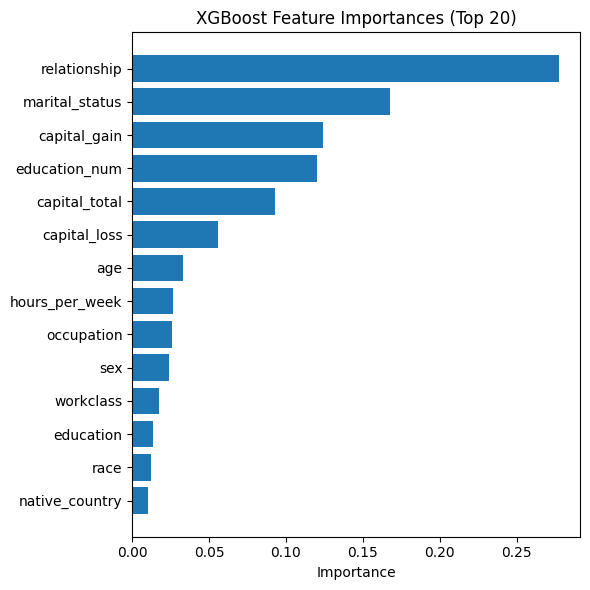

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# feature importance 값
importances = xgb.feature_importances_
feature_names = x_train.columns  # 이미 전처리된 피처 이름들

# 중요도 상위 20개 뽑기
idx = np.argsort(importances)[::-1]  # 중요도 큰 순서로 정렬 인덱스
top_n = 20
top_idx = idx[:top_n]

top_features = feature_names[top_idx]
top_importances = importances[top_idx]

# 표 형태로 보고 싶으면
feat_imp_df = pd.DataFrame({
    "feature": top_features,
    "importance": top_importances
})
print(feat_imp_df)

# 막대그래프 시각화
plt.figure(figsize=(6, 6))
plt.barh(top_features[::-1], top_importances[::-1])  # 위가 가장 중요하게 보이도록 뒤집기
plt.xlabel("Importance")
plt.title("XGBoost Feature Importances (Top 20)")
plt.tight_layout()
plt.show()


sex groups: [0 1]
   group        F1       AUC  Precision    Recall
0  sex=0  0.735504  0.965489   0.840290  0.653955
1  sex=1  0.745532  0.928375   0.808072  0.691978


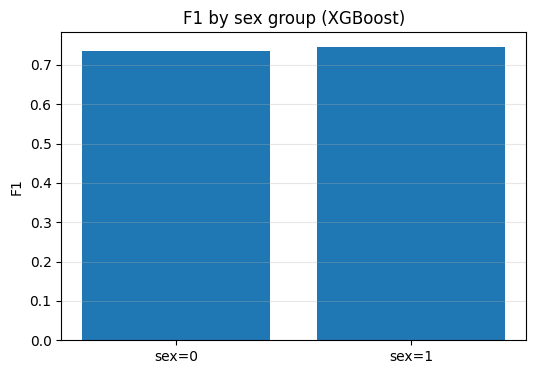

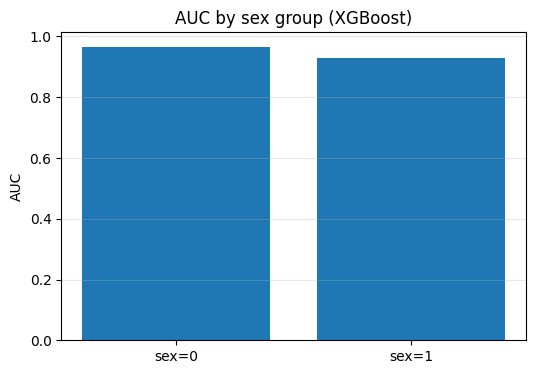

In [ ]:
X_all = train_X_df.drop(columns=['id'], errors='ignore')
y_all = train_y_df.squeeze()

sex_values = train["sex"].unique()
print("sex groups:", sex_values)

rows = []
for s in sex_values:
    idx = (train["sex"] == s)

    X_grp = X_all[idx]
    y_grp = y_all[idx]

    y_prob_grp = xgb.predict_proba(X_grp)[:, 1]
    y_pred_grp = (y_prob_grp >= 0.5).astype(int)

    f1  = f1_score(y_grp, y_pred_grp)
    auc = roc_auc_score(y_grp, y_prob_grp)
    prec = precision_score(y_grp, y_pred_grp)
    rec  = recall_score(y_grp, y_pred_grp)

    rows.append({
        "group": f"sex={s}",
        "F1": f1,
        "AUC": auc,
        "Precision": prec,
        "Recall": rec
    })

fair_sex_df = pd.DataFrame(rows)
print(fair_sex_df)

plt.figure(figsize=(6, 4))
plt.bar(fair_sex_df["group"], fair_sex_df["F1"])
plt.ylabel("F1")
plt.title("F1 by sex group (XGBoost)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(fair_sex_df["group"], fair_sex_df["AUC"])
plt.ylabel("AUC")
plt.title("AUC by sex group (XGBoost)")
plt.grid(axis="y", alpha=0.3)
plt.show()

marital_status groups: [0 4 2 3 5 6 1]
              group        F1       AUC  Precision    Recall
0  marital_status=0  0.621194  0.925258   0.917266  0.469613
1  marital_status=4  0.619750  0.968169   0.931741  0.464286
2  marital_status=2  0.760511  0.885071   0.801612  0.723420
3  marital_status=3  0.619718  0.957028   0.916667  0.468085
4  marital_status=5  0.611570  0.951989   0.902439  0.462500
5  marital_status=6  0.671053  0.957757   1.000000  0.504950
6  marital_status=1  0.533333  0.812865   0.666667  0.444444


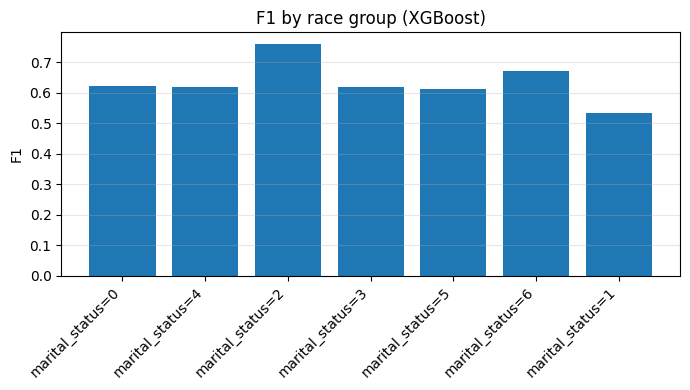

In [ ]:
marital_status_values = train["marital_status"].unique()
print("marital_status groups:", marital_status_values)

rows = []
for r in marital_status_values:
    idx = (train["marital_status"] == r)

    X_grp = X_all[idx]
    y_grp = y_all[idx]

    y_prob_grp = xgb.predict_proba(X_grp)[:, 1]
    y_pred_grp = (y_prob_grp >= 0.5).astype(int)

    f1  = f1_score(y_grp, y_pred_grp)
    auc = roc_auc_score(y_grp, y_prob_grp)
    prec = precision_score(y_grp, y_pred_grp)
    rec  = recall_score(y_grp, y_pred_grp)

    rows.append({
        "group": f"marital_status={r}",
        "F1": f1,
        "AUC": auc,
        "Precision": prec,
        "Recall": rec
    })

fair_race_df = pd.DataFrame(rows)
print(fair_race_df)

# 간단 시각화
plt.figure(figsize=(7, 4))
plt.bar(fair_race_df["group"], fair_race_df["F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1")
plt.title("F1 by race group (XGBoost)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

relationship groups: [1 5 0 3 4 2]
   group        F1       AUC  Precision    Recall
0  rel=1  0.629962  0.941685   0.919626  0.479065
1  rel=5  0.805764  0.901608   0.808092  0.803448
2  rel=0  0.755675  0.881514   0.800253  0.715801
3  rel=3  0.559322  0.964819   0.970588  0.392857
4  rel=4  0.597260  0.946154   0.947826  0.436000
5  rel=2  0.603175  0.977718   1.000000  0.431818


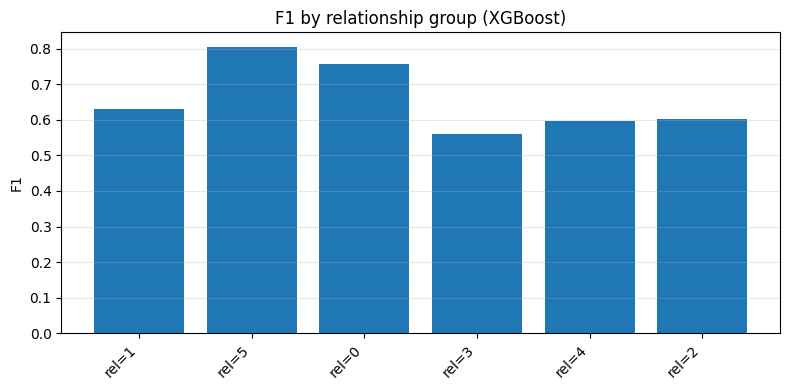

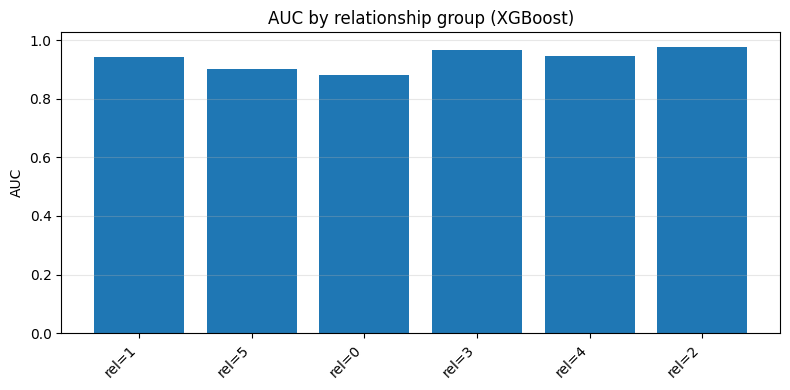

In [ ]:
rel_values = train["relationship"].unique()
print("relationship groups:", rel_values)

rows = []
for r in rel_values:
    idx = (train["relationship"] == r)

    X_grp = X_all[idx]
    y_grp = y_all[idx]

    y_prob_grp = xgb.predict_proba(X_grp)[:, 1]
    y_pred_grp = (y_prob_grp >= 0.5).astype(int)

    f1  = f1_score(y_grp, y_pred_grp)
    auc = roc_auc_score(y_grp, y_prob_grp)
    prec = precision_score(y_grp, y_pred_grp)
    rec  = recall_score(y_grp, y_pred_grp)

    rows.append({
        "group": f"rel={r}",
        "F1": f1,
        "AUC": auc,
        "Precision": prec,
        "Recall": rec
    })

fair_rel_df = pd.DataFrame(rows)
print(fair_rel_df)

# F1
plt.figure(figsize=(8, 4))
plt.bar(fair_rel_df["group"], fair_rel_df["F1"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1")
plt.title("F1 by relationship group (XGBoost)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# AUC
plt.figure(figsize=(8, 4))
plt.bar(fair_rel_df["group"], fair_rel_df["AUC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC")
plt.title("AUC by relationship group (XGBoost)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Hyperparameter Tuning

## (1) 교차검증 (K-Fold)

In [ ]:
# F1, AUC, Score 평균/표준편차 반환
def cv_score(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    f1s, aucs = [], []

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_val)[:, 1]

        f1s.append(f1_score(y_val, (y_prob >= 0.5).astype(int)))
        aucs.append(roc_auc_score(y_val, y_prob))

    f1_mean,  f1_std  = np.mean(f1s),  np.std(f1s)
    auc_mean, auc_std = np.mean(aucs), np.std(aucs)
    score_mean = (f1_mean + auc_mean) / 2
    return {
        'F1':    f'{f1_mean:.4f} ± {f1_std:.4f}',
        'AUC':   f'{auc_mean:.4f} ± {auc_std:.4f}',
        'Score': f'{score_mean:.4f}',
        '_score': score_mean   # 정렬용 숫자값
    }

In [ ]:
baseline_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight="balanced"),

    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42),
}

print(f"{'모델':<22} {'F1':^22} {'AUC':^22} {'Score':>8}")
print('-' * 78)

rows = []
for name, model in baseline_models.items():
    res = cv_score(model, x_train, y_train)
    rows.append({'Model': name, **res})
    print(f"{name:<22} {res['F1']:^22} {res['AUC']:^22} {res['Score']:>8}")

baseline_df = pd.DataFrame(rows).sort_values('_score', ascending=False)
best_baseline = baseline_df.iloc[0]['Model']
print(f"\nBaseline 최고 모델: {best_baseline}")

모델                               F1                    AUC              Score
------------------------------------------------------------------------------
LogisticRegression        0.6113 ± 0.0061        0.8528 ± 0.0032       0.7321
RandomForest              0.6539 ± 0.0057        0.9013 ± 0.0044       0.7776
XGBoost                   0.7114 ± 0.0049        0.9276 ± 0.0034       0.8195

Baseline 최고 모델: XGBoost


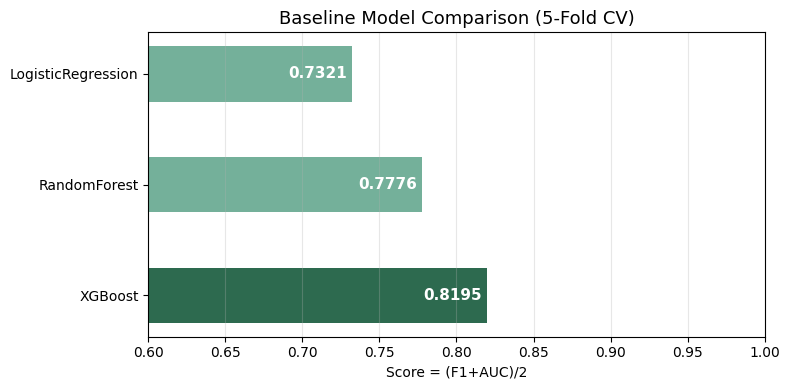

In [ ]:
# Baseline 성능 시각화
fig, ax = plt.subplots(figsize=(8, 4))

models    = baseline_df['Model'].tolist()
scores    = baseline_df['_score'].tolist()
colors    = ['#2d6a4f' if m == best_baseline else '#74b09a' for m in models]

bars = ax.barh(models, scores, color=colors, height=0.5)
for bar, score in zip(bars, scores):
    ax.text(score - 0.003, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', ha='right',
            color='white', fontsize=11, fontweight='bold')

ax.set_xlim(0.6, 1.0)
ax.set_xlabel('Score = (F1+AUC)/2')
ax.set_title('Baseline Model Comparison (5-Fold CV)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## (2) 하이퍼파라미터 튜닝 (Optuna)

In [ ]:
# Optuna objective wrapper
def make_objective(model_fn, X, y):
    def objective(trial):
        model = model_fn(trial)
        res   = cv_score(model, X, y)
        return res['_score']
    return objective

In [ ]:
# Logistic Regression
def lr_fn(trial):
    return LogisticRegression(
        C         = trial.suggest_float('C', 1e-3, 100, log=True),
        solver    = trial.suggest_categorical('solver', ['lbfgs', 'saga']),
        max_iter  = 2000,
        class_weight = 'balanced',
        n_jobs=-1, random_state=42)

study_lr = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(make_objective(lr_fn, x_train, y_train),
                  n_trials=30, show_progress_bar=True)

print(f"\n[LR]  Best Score: {study_lr.best_value:.4f}")
print(f"      Best Params: {study_lr.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


[LR]  Best Score: 0.7322
      Best Params: {'C': 0.04096777947742616, 'solver': 'lbfgs'}


In [ ]:
# Random Forest
def rf_fn(trial):
    return RandomForestClassifier(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600, step=100),
        max_depth        = trial.suggest_int('max_depth', 5, 30),
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        class_weight='balanced', n_jobs=-1, random_state=42)

study_rf = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(make_objective(rf_fn, x_train, y_train),
                  n_trials=30, show_progress_bar=True)

print(f"\n[RF]  Best Score: {study_rf.best_value:.4f}")
print(f"      Best Params: {study_rf.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


[RF]  Best Score: 0.8143
      Best Params: {'n_estimators': 400, 'max_depth': 26, 'min_samples_leaf': 2, 'max_features': 'log2'}


In [ ]:
# XGBoost (scale_pos_weight 포함)
# 데이터 비율로 탐색 범위 자동 계산
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class 비율 (0/1): {pos_weight:.2f}  →  scale_pos_weight 탐색 범위: 1.0 ~ {pos_weight * 2:.2f}')

def xgb_fn(trial):
    return XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800, step=100),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 9),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0, 1),
        scale_pos_weight  = trial.suggest_float('scale_pos_weight', 1.0, pos_weight * 2),
        objective='binary:logistic', eval_metric='logloss',
        n_jobs=-1, random_state=42, verbosity=0)

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(make_objective(xgb_fn, x_train, y_train),
                   n_trials=50, show_progress_bar=True)

print(f"\n[XGB] Best Score: {study_xgb.best_value:.4f}")
print(f"      Best Params: {study_xgb.best_params}")

Class 비율 (0/1): 3.18  →  scale_pos_weight 탐색 범위: 1.0 ~ 6.36


  0%|          | 0/50 [00:00<?, ?it/s]


[XGB] Best Score: 0.8272
      Best Params: {'n_estimators': 200, 'learning_rate': 0.054896962741489946, 'max_depth': 8, 'subsample': 0.6661043278643606, 'colsample_bytree': 0.6026602459752114, 'reg_alpha': 0.24418024878041397, 'reg_lambda': 0.001159662893697173, 'min_child_weight': 1, 'gamma': 0.06502618915438668, 'scale_pos_weight': 1.4989803115552758}


## (3) 평가

In [ ]:
# ── 튜닝된 XGBoost로 전체 train 재학습 ───────────────────────
best_model = XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic', eval_metric='logloss',
    n_jobs=-1, random_state=42, verbosity=0)

best_model.fit(x_train, y_train)

# 튜닝된 파라미터로 CV 재평가
tuned_model = XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic', eval_metric='logloss',
    n_jobs=-1, random_state=42, verbosity=0)

result = cv_score(tuned_model, x_train, y_train)
print(f'[튜닝 후 CV 성능]')
print(f'  F1:    {result["F1"]}')
print(f'  AUC:   {result["AUC"]}')
print(f'  Score: {result["Score"]}')

# CV Score (튜닝 결과)
print(f'\nXGBoost Tuned  |  CV Score: {study_xgb.best_value:.4f}')

# Train 성능 (참고용 — CV 수치와 크게 차이나면 과적합 의심)
y_prob_train = best_model.predict_proba(x_train)[:, 1]
y_pred_train = (y_prob_train >= 0.5).astype(int)
f1_train  = f1_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_prob_train)
print(f'\n[Train 성능 - 참고용]')
print(f'  F1:    {f1_train:.4f}')
print(f'  AUC:   {auc_train:.4f}')
print(f'  Score: {(f1_train + auc_train)/2:.4f}')

[튜닝 후 CV 성능]
  F1:    0.7268 ± 0.0073
  AUC:   0.9276 ± 0.0035
  Score: 0.8272

XGBoost Tuned  |  CV Score: 0.8272

[Train 성능 - 참고용]
  F1:    0.7662
  AUC:   0.9499
  Score: 0.8580


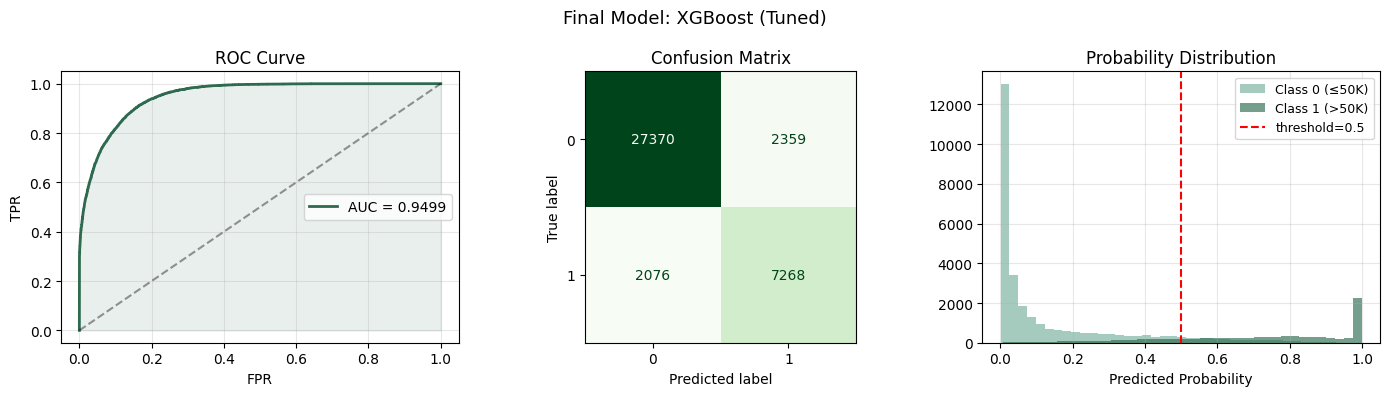

In [ ]:
# ── 최종 모델 평가 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Final Model: XGBoost (Tuned)', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_train, y_prob_train)
axes[0].plot(fpr, tpr, color='#2d6a4f', lw=2,
             label=f'AUC = {auc_train:.4f}')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2d6a4f')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix')

# 예측 확률 분포
axes[2].hist(y_prob_train[y_train==0], bins=40, alpha=0.65,
             label='Class 0 (≤50K)', color='#74b09a')
axes[2].hist(y_prob_train[y_train==1], bins=40, alpha=0.65,
             label='Class 1 (>50K)', color='#2d6a4f')
axes[2].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title('Probability Distribution')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## (4) 예측

In [ ]:
# processed_X_test.csv에 id 컬럼이 포함되어 있음

y_prob_test = best_model.predict_proba(test_X_df)[:, 1]
y_cls_test  = (y_prob_test >= 0.5).astype(int)

submission = pd.DataFrame({
    'id':     test_id,
    'y_cls':  y_cls_test,
    'y_prob': y_prob_test
})
# submission.to_csv('prediction.csv', index=False)
# print('prediction.csv 저장 완료')
print(f'   Class 0: {(y_cls_test==0).sum():,}  |  Class 1: {(y_cls_test==1).sum():,}')
submission.head()

   Class 0: 7,355  |  Class 1: 2,414


,id,y_cls,y_prob
0,7763,0,0.006504
1,23882,0,0.389086
2,30508,0,0.141759
3,28912,1,0.997289
4,19485,0,0.000555


# 4. Additional Tuning

In [ ]:
# threshold 후보 중 validation F1이 가장 높은 threshold 반환
def find_best_threshold(y_true, y_prob):
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.25, 0.75, 0.01):
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1

**수정 → CV 평가 시 0.5 고정 threshold 대신 fold별 최적 threshold 적용**

In [ ]:
# threshold 최적화 후 F1, AUC, Score 평균/표준편차 반환
def cv_score(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    f1s = []
    aucs = []
    thresholds = []

    for tr_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)

        y_prob = model.predict_proba(X_val)[:, 1]

        best_t, best_f1 = find_best_threshold(y_val, y_prob)

        f1s.append(best_f1)
        aucs.append(roc_auc_score(y_val, y_prob))
        thresholds.append(best_t)

    f1_mean = np.mean(f1s)
    f1_std = np.std(f1s)

    auc_mean = np.mean(aucs)
    auc_std = np.std(aucs)

    score_mean = (f1_mean + auc_mean) / 2

    return {
        "F1": f"{f1_mean:.4f} ± {f1_std:.4f}",
        "AUC": f"{auc_mean:.4f} ± {auc_std:.4f}",
        "Score": f"{score_mean:.4f}",
        "_score": score_mean,   # 정렬용 숫자값
        "best_threshold": np.mean(thresholds)
    }

In [ ]:
# XGBoost (scale_pos_weight 포함)
# 데이터 비율로 탐색 범위 자동 계산
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class 비율 (0/1): {pos_weight:.2f}  →  scale_pos_weight 탐색 범위: 1.0 ~ {pos_weight * 2:.2f}')

def xgb_fn(trial):
    return XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 100, 800, step=100),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 9),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0, 1),
        scale_pos_weight  = trial.suggest_float('scale_pos_weight', 1.0, pos_weight * 2),
        objective='binary:logistic', eval_metric='logloss',
        n_jobs=-1, random_state=42, verbosity=0)

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(make_objective(xgb_fn, x_train, y_train),
                   n_trials=50, show_progress_bar=True)

print(f"\n[XGB] Best Score: {study_xgb.best_value:.4f}")
print(f"      Best Params: {study_xgb.best_params}")

Class 비율 (0/1): 3.18  →  scale_pos_weight 탐색 범위: 1.0 ~ 6.36


  0%|          | 0/50 [00:00<?, ?it/s]


[XGB] Best Score: 0.8299
      Best Params: {'n_estimators': 800, 'learning_rate': 0.01633439963571872, 'max_depth': 8, 'subsample': 0.9325583755827239, 'colsample_bytree': 0.5682593096917011, 'reg_alpha': 0.0011257618839144135, 'reg_lambda': 0.0012675217899958163, 'min_child_weight': 2, 'gamma': 0.41715380827608756, 'scale_pos_weight': 1.3865911429728977}


In [ ]:
best_model = XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

cv_result = cv_score(best_model, x_train, y_train)

print(f'XGBoost Tuned | CV Score: {cv_result["_score"]:.4f}')

best_threshold = cv_result["best_threshold"]

print(f'Best Threshold: {best_threshold:.2f}')

best_model.fit(x_train, y_train)

y_prob_train = best_model.predict_proba(x_train)[:, 1]

y_pred_train = (
    y_prob_train >= best_threshold
).astype(int)

f1_train = f1_score(y_train, y_pred_train)
auc_train = roc_auc_score(y_train, y_prob_train)

print(f'\n[Train 성능 - 참고용]')
print(f'F1: {f1_train:.4f}')
print(f'AUC: {auc_train:.4f}')
print(f'Score:{(f1_train + auc_train) / 2:.4f}')

XGBoost Tuned | CV Score: 0.8299
Best Threshold: 0.47

[Train 성능 - 참고용]
F1: 0.7668
AUC: 0.9496
Score:0.8582


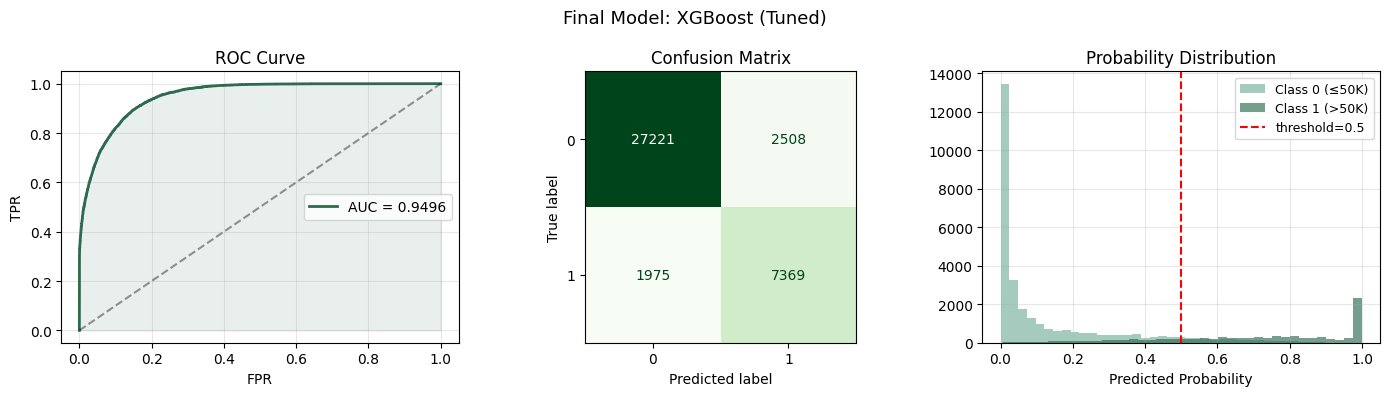

In [ ]:
# ── 최종 모델 평가 시각화 ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Final Model: XGBoost (Tuned)', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_train, y_prob_train)
axes[0].plot(fpr, tpr, color='#2d6a4f', lw=2,
             label=f'AUC = {auc_train:.4f}')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2d6a4f')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_train, y_pred_train)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix')

# 예측 확률 분포
axes[2].hist(y_prob_train[y_train==0], bins=40, alpha=0.65,
             label='Class 0 (≤50K)', color='#74b09a')
axes[2].hist(y_prob_train[y_train==1], bins=40, alpha=0.65,
             label='Class 1 (>50K)', color='#2d6a4f')
axes[2].axvline(0.5, color='red', linestyle='--', label='threshold=0.5')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_title('Probability Distribution')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. 제출 파일 생성

In [ ]:
y_prob_test = best_model.predict_proba(test_X_df)[:, 1]

# ---------- Modified Threshold Tuning -----------

y_cls_test = (y_prob_test >= best_threshold).astype(int)

# ------------------------------------------------

submission = pd.DataFrame({
    'id':     test_id,
    'y_cls':  y_cls_test,
    'y_prob': y_prob_test
})
submission.to_csv('prediction.csv', index=False)
print('prediction.csv 저장 완료')
print(f'   Class 0: {(y_cls_test==0).sum():,}  |  Class 1: {(y_cls_test==1).sum():,}')
submission.head()

prediction.csv 저장 완료
   Class 0: 7,303  |  Class 1: 2,466


,id,y_cls,y_prob
0,7763,0,0.005104
1,23882,0,0.363821
2,30508,0,0.179894
3,28912,1,0.999397
4,19485,0,0.000584




---

# ATTEMPTED FAILURES

In [ ]:
'''
import numpy as np
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from xgboost import XGBClassifier

def add_important_feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1) capital 계열: log(1+x) + >0 여부 (이미 숫자형이라 그대로 사용 가능)
    for col in ['capital_gain', 'capital_loss', 'capital_total']:
        if col in df.columns:
            df[f'{col}_log1p'] = np.log1p(df[col].clip(lower=0))
            df[f'{col}_gt0']   = (df[col] > 0).astype(int)

    # 2) education_num 기반 고학력 여부 (education_num도 이미 숫자형)
    if 'education_num' in df.columns:
        # threshold는 필요에 따라 조정 (여기선 예시로 13 그대로 사용)
        df['high_edu'] = (df['education_num'] >= 13).astype(int)

    return df

# =======================
# 0. id 제거
# =======================
X_train_nid = X_train.drop(columns=['id'])
X_val_nid   = X_val.drop(columns=['id'])

# =======================
# 1. 1D array로 변환
# =======================
y_train_arr = y_train.values.ravel()
y_val_arr   = y_val.values.ravel()

# =======================
# 2. scale_pos_weight 계산 (train 기준)
# =======================
pos_weight = (y_train_arr == 0).sum() / (y_train_arr == 1).sum()
print(f'Class 비율 (0/1): {pos_weight:.2f}  →  scale_pos_weight 탐색 범위: 1.0 ~ {pos_weight * 2:.2f}')

# =======================
# 3. (F1 + AUC) / 2 스코어러 정의 (참고용)
# =======================
combined_scorer = make_scorer(
    lambda y_true, y_proba: 0.5 * (
        f1_score(y_true, (y_proba >= 0.5).astype(int)) +
        roc_auc_score(y_true, y_proba)
    ),
    needs_proba=True
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# =======================
# 4. Optuna objective (id 제거된 X 사용, 전체 피처 사용)
# =======================
def objective(trial):
    model = XGBClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 200, 800, step=100),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 5, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 5, log=True),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 8),
        gamma             = trial.suggest_float('gamma', 0.0, 1.0),
        scale_pos_weight  = trial.suggest_float('scale_pos_weight', 1.0, float(pos_weight) * 2),

        objective='binary:logistic',
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )

    scores = []
    for train_idx, valid_idx in cv.split(X_train_nid, y_train_arr):
        X_tr, X_va = X_train_nid.iloc[train_idx], X_train_nid.iloc[valid_idx]
        y_tr, y_va = y_train_arr[train_idx], y_train_arr[valid_idx]

        model.fit(X_tr, y_tr)
        probs = model.predict_proba(X_va)[:, 1]
        preds = (probs >= 0.5).astype(int)

        try:
            f1  = f1_score(y_va, preds)
            auc = roc_auc_score(y_va, probs)
            s   = 0.5 * (f1 + auc)
        except ValueError:
            continue

        if np.isnan(s):
            continue

        scores.append(s)

    if len(scores) == 0:
        raise optuna.TrialPruned()

    return float(np.mean(scores))

# =======================
# 5. Study 생성 및 최적화
# =======================
study_xgb = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_xgb.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print(f"\n[XGB] Best Score (CV): {study_xgb.best_value:.4f}")
print(f"      Best Params: {study_xgb.best_params}")

# =======================
# 6. Best Params로 전체 train(id 제거) 재학습 (전체 피처 사용)
# =======================
best_params = study_xgb.best_params.copy()

best_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    **best_params
)

best_model.fit(X_train_nid, y_train_arr)

# =======================
# 7. Val 성능 평가 + threshold 튜닝
# =======================
probs_val = best_model.predict_proba(X_val_nid)[:, 1]

best_thresh, best_f1 = 0.5, 0
for t in np.linspace(0.1, 0.9, 81):
    f1 = f1_score(y_val_arr, (probs_val >= t).astype(int))
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

auc_val = roc_auc_score(y_val_arr, probs_val)
print("\n[Val 결과 - 전체 피처 (id 제거)]")
print("  thresh :", best_thresh)
print("  F1     :", best_f1)
print("  AUC    :", auc_val)
print("  Score  :", (best_f1 + auc_val) / 2)
'''